# ESdE Adultos 2023: Dataset integrity and population-representation

## Introduction

The scope of the notebook is to verify and document the usage of public-use ESdE 2023 adult microdata of this project, as part of validation foundation for future question-specific analysis.

General population variables will be used to display differences between sample calculations and weighted estimated through the use of the provided elevation factor as weighted calibration. 

Its intention is not to reproduce/audit INE's weighting [methodology](https://www.ine.es/metodologia/t15/esde23_meto.pdf), nor evaluate the official [non-response report](https://www.ine.es/metodologia/t15/esde23_falta_res.pdf). 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ine_health_data.pipeline import load_variables, start_setup, is_nonresponse, get_codebook, get_metadata_df, add_value_labels
start_setup() 

## Dataset structure and response screening

### General dataset shape

According to INEs methodology, the number of completed adult questionnaires was 21040 out of 21085 surveyed households.
However in the non-response report, 21077 households were included, with 45 total indicences of non-response.

In the dataset, the total number of rows should represent the number of surveyed adults, which can be contrasted with the household ID `IDENTHOGAR` due to its uniqueness as the sample selects for one adult 15+ whithin each household. 

In [2]:
all_raw_data = load_variables()
pd.Series({
    "n rows": f"{len(all_raw_data):,.0f}",
    "n cols": f"{len(all_raw_data.columns):,.0f}",
    "n IDENTHOGAR": f"{all_raw_data["IDENTHOGAR"].count():,.0f}",
    "n NaN IDENTHOGAR": all_raw_data["IDENTHOGAR"].isna().sum(),
    "max IDENTHOGAR ID": all_raw_data["IDENTHOGAR"].max(),
    "duplicated IDENTHOGAR": all_raw_data["IDENTHOGAR"].duplicated().sum(),
}).to_frame(name="value")

,value
n rows,"21,032"
n cols,432
n IDENTHOGAR,"21,032"
n NaN IDENTHOGAR,0
max IDENTHOGAR ID,0021077
duplicated IDENTHOGAR,0


The dataset available contains 21032 rows, indicating fewer completed adult questionnaires than reported by methodology document. 
However, based on the non-response document, the count is explained by the 45 incidences of the 21077 household reported, resulting in a total of 21032 surveyed adults.

The discrepancy of 8 records from both INE's official documents is not explained within any of both, and will be ignored due to being out of the scope of this project. 


The amount of columns loaded from the full dataset are in accordance to the number of variables described in the codebook adjacent to the dataset raw file.

### Questionnaire routing missingness and item non-response  

As the questionnaire contains conditional response fields that depend on previous answers, it is important to differentiate between routed-out questions, which should be represented with a missing/blank value, and "non-response" or "non-applicable" represented with special code responses.

The table below provides a general overview of non-responses and re-routed blanks.

In [3]:
total_cells = all_raw_data.size
codebook = get_codebook()

blank_series = all_raw_data.isna().sum()
no_contesta_series = is_nonresponse(df=all_raw_data,nona_labels="No contesta",codebook=codebook).sum()
no_aplicable_series = is_nonresponse(df=all_raw_data,nona_labels="No aplicable",codebook=codebook).sum()
no_consta_series = is_nonresponse(df=all_raw_data,nona_labels="No consta",codebook=codebook).sum()

count = pd.Series({
    "Total cells":f"{total_cells:,.0f}",
    "Blanks":f"{blank_series.sum():,.0f}",
    "'No contesta'": f"{no_contesta_series.sum():,.0f}",
    "'No aplicable'": f"{no_aplicable_series.sum():,.0f}",
    "'No consta'": f"{no_consta_series.sum():,.0f}"
})
pct = pd.Series({
    "Total cells": 100,
    "Blanks":(blank_series.sum()/total_cells)*100,
    "'No contesta'": (no_contesta_series.sum()/total_cells)*100,
    "'No aplicable'": (no_aplicable_series.sum()/total_cells)*100,
    "'No consta'": (no_consta_series.sum()/total_cells)*100,
}).round(2)
summary = pd.concat({
        "n":count,
        "%":pct
    },axis=1
).sort_values(by="%",ascending=False)

display(summary)
total_nonresp = no_contesta_series.sum()+no_consta_series.sum()
display(f"Total coded Non-response = {total_nonresp:,.0f}; {(total_nonresp/total_cells*100).round(2)}%")

,n,%
Total cells,"9,085,824",100.00
Blanks,"4,122,552",45.37
'No contesta',"45,068",0.50
'No consta',"2,395",0.03
'No aplicable',"2,165",0.02


'Total coded Non-response = 47,463; 0.52%'

Specific patterns in the dataset per variable group can be seen in the table below.

In [4]:
metadata_df = get_metadata_df(metadata_fields="Grupo")
total_cells_series = pd.Series(
    len(all_raw_data),
    index=all_raw_data.columns,
)
per_group_count = (
    pd.DataFrame({
        "total cells": total_cells_series, 
        "blanks": blank_series, 
        "'No contesta'": no_contesta_series, 
        "'No aplicable'": no_aplicable_series, 
        "'No consta'": no_consta_series
    })
    .join(metadata_df, how="left")
    .groupby("Grupo",sort=False) 
    .sum()
)
per_group_pct = (
    per_group_count
    .div(per_group_count["total cells"], axis=0)
    .mul(100).round(2)
    .drop(columns="total cells")
    .add_suffix(" (%)") 
).rename_axis(None)
display(per_group_pct)

,blanks (%),'No contesta' (%),'No aplicable' (%),'No consta' (%)
DATOS DE IDENTIFICACIÓN,0.00,0.00,0.00,0.00
IDENTIFICACIÓN DEL PROXY,83.91,0.00,0.00,0.00
A. CARACTERÍSTICAS DEMOGRÁFICAS DE LA PERSONA ADULTA SELECCIONADA,8.75,1.11,0.00,0.00
B. RELACIÓN DE LA PERSONA ADULTA SELECCIONADA CON LA ACTIVIDAD ECONÓMICA,73.66,0.34,0.00,0.00
C. ESTADO DE SALUD,59.66,0.35,0.00,0.00
D. ACCIDENTALIDAD,23.05,0.17,0.00,0.00
E. AUSENCIA DEL TRABAJO POR PROBLEMAS DE SALUD,70.48,0.79,0.00,0.00
F. LIMITACIONES FÍSICAS Y SENSORIALES,5.62,0.19,0.00,0.00
G. LIMITACIONES PARA LA REALIZACIÓN DE LAS ACTIVIDADES DE LA VIDA COTIDIANA,54.65,0.12,0.27,0.00
H. ESTRÉS Y SATISFACCIÓN LABORAL,53.05,0.66,0.00,0.00


The high number of blank values are to be expected due to routing-related missingness.
Coded special values are more direct indicators of response status. 

Question-specific routing and eligible denominators will be validated when variables are selected for focused EDA.

## Survey weights and population representation

The purpose of this section is to apply the final calibrated adult elevation factor (`FACTORADULTO`) supplied with the ESdE 2023 microdata and display changes in weighted estimates of the adult population’s age, sex, and geographic composition relative to the unweighted sample.

### Variables check

General population variables used include age (`EDADa`), sex (`SEXOa`), geographical location (`CCAA`), and the adult survey weight (`FACTORADULTO`).

Both `EDADa` and `FACTORADULTO` are numerical variables, with `EDADa` using the special coded value `999` to indicate non-response "No contesta".
Both `SEXOa`, `CCAA`, are categorical, with no special coded non-response values. For `SEXOa` there are two valid categorical values, and for `CCAA` 19.

In [5]:
raw_pop_df = load_variables(variables=["EDADa","SEXOa","CCAA","FACTORADULTO"])

summary_pop_var = pd.Series({
    "Rows any with empty": raw_pop_df.isna().any(axis=1).sum(),
    "non-response age rows": raw_pop_df["EDADa"].eq(999).sum(),
    "unique CCAA count": len(raw_pop_df["CCAA"].unique()),
    "unique SEXOa values": len(raw_pop_df["SEXOa"].unique()),
    "age range": f"{raw_pop_df["EDADa"].min()} - {raw_pop_df["EDADa"].max()}",
    "estimated represented adult pop": f"{raw_pop_df["FACTORADULTO"].sum():,.0f}"
}).to_frame(name="n")
display(summary_pop_var)

,n
Rows any with empty,0
non-response age rows,0
unique CCAA count,19
unique SEXOa values,2
age range,15 - 103
estimated represented adult pop,"41,929,276"


The dataset does not contain blanks nor special coded non-response values for the selected general population variables.

The observed ages fall within the documented valid range of 15-120, and similar for the categorical values of sex and geographic location.
For adult point weight `FACTORADULTO`, its sum is approximate to the reported 41.4 Million reported by INE's demographic data. 

All 21032 adult records are therefore retained for the population-representation comparisons.

### Age and sex

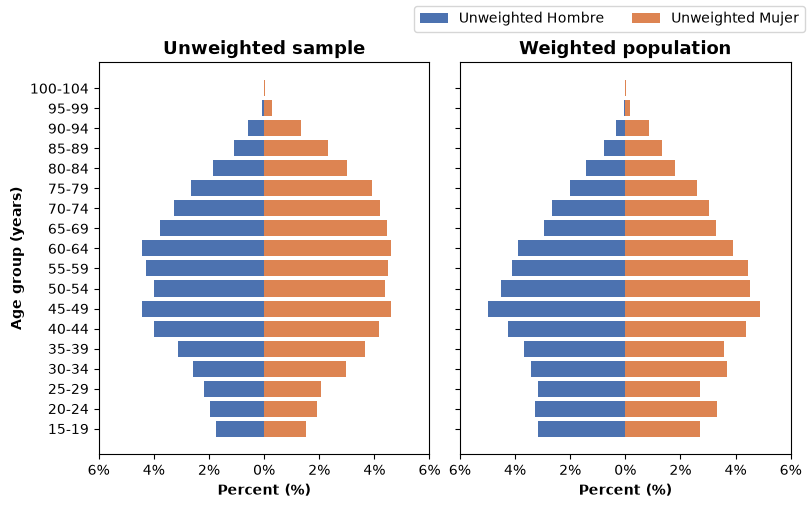

In [6]:
label_df = add_value_labels(raw_pop_df).drop(columns="EDADa_label")

age_sex_df = label_df.copy().drop(columns=["CCAA","CCAA_label"])
age_sex_df["age_band"] = pd.cut(
    age_sex_df["EDADa"],
    bins=list(range(15, 110, 5)),
    right=False,
    ordered=True,
)
age_per_band_pct = (
    age_sex_df
    .groupby(["SEXOa_label", "age_band"], observed=False)
    .agg(
        unweighted_n=("EDADa", "size"),
        weighted_n=("FACTORADULTO", "sum"),
    )
    .reset_index()
    .assign(
        unweighted_pct=lambda df: (
            df["unweighted_n"] / df["unweighted_n"].sum() * 100
        ),
        weighted_pct=lambda df: (
            df["weighted_n"] / df["weighted_n"].sum() * 100
        ),
        age_band = lambda df: (
            df["age_band"].map(lambda interval: f"{interval.left:g}-{interval.right - 1:g}")
        ) 
    )
    .drop(columns=["unweighted_n", "weighted_n"])
)

fig, ax = plt.subplots(1, 2, sharex=False, sharey=True, layout="constrained",figsize=(8,5))
males = age_per_band_pct["SEXOa_label"] == "Hombre"
ax[0].barh(
    age_per_band_pct.loc[males, "age_band"].astype(str),
    -age_per_band_pct.loc[males, "unweighted_pct"], 
    color="#4c72b0", 
    label="Unweighted Hombre"
)
ax[0].barh(
    age_per_band_pct.loc[~males, "age_band"].astype(str), 
    age_per_band_pct.loc[~males, "unweighted_pct"], 
    color="#dd8452", 
    label="Unweighted Mujer"
)
ax[1].barh(
    age_per_band_pct.loc[males, "age_band"].astype(str),
    -age_per_band_pct.loc[males, "weighted_pct"], 
    color="#4c72b0", 
    label="Weighted Hombre"
)
ax[1].barh(
    age_per_band_pct.loc[~males, "age_band"].astype(str), 
    age_per_band_pct.loc[~males, "weighted_pct"], 
    color="#dd8452", 
    label="Weighted Mujer"
)

for axis in ax:
    axis.set_xticks(range(-6, 7,2),  [f"{abs(value)}%" for value in range(-6,7,2)])
    axis.set_xlabel("Percent (%)", fontsize=10, fontweight="bold")

ax[0].set_title("Unweighted sample", fontsize=13, fontweight="bold")
ax[1].set_title("Weighted population", fontsize=13, fontweight="bold")

ax[0].set_ylabel("Age group (years)", fontsize=10, fontweight="bold")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,  loc="outside upper right", ncols=2)

plt.show()


### Sample geographic distribution

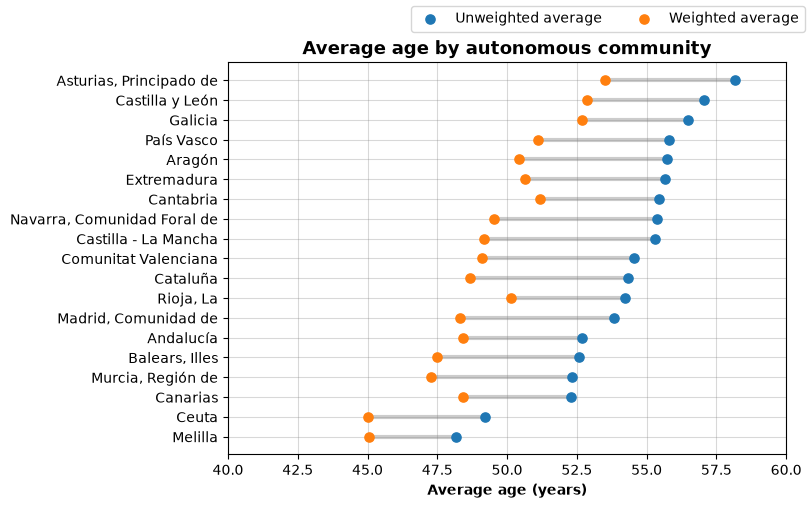

In [7]:
ccaa_ages_avg = (
    label_df
    .groupby(["CCAA", "CCAA_label"], observed=False)
    .apply(
        lambda group: pd.Series({
            "unweighted_avg": group["EDADa"].mean(),
            "weighted_avg": (
                (group["EDADa"] * group["FACTORADULTO"]).sum()
                / group["FACTORADULTO"].sum()
            ),
        })
    )
    .sort_values("unweighted_avg")
    .reset_index()
)

fig, ax = plt.subplots(layout="constrained",  figsize=(8,5))

ccaa_range = range(ccaa_ages_avg["CCAA_label"].nunique())
ax.hlines(
    y=ccaa_range, 
    xmin=ccaa_ages_avg['unweighted_avg'], 
    xmax=ccaa_ages_avg['weighted_avg'], 
    color='grey', alpha=0.4,linewidth=3
)
ax.scatter(
    ccaa_ages_avg['unweighted_avg'], 
    ccaa_range, 
    s=44, 
    zorder=2,
    label="Unweighted average",
)
ax.scatter(
    ccaa_ages_avg['weighted_avg'], 
    ccaa_range, 
    s=44, 
    zorder=2,
    label="Weighted average"
)

ax.set_title("Average age by autonomous community", fontsize=13, fontweight="bold")
ax.set_xlabel("Average age (years)", fontsize=10, fontweight="bold")
ax.set_xlim(40, 60)
ax.grid(color="grey", alpha=0.3, linewidth=0.8)

labels_str = ccaa_ages_avg["CCAA_label"].unique().tolist()
ax.set_yticks(ccaa_range, labels_str)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,  loc="outside upper right", ncols=2)

plt.show()